In [16]:
# %% [markdown]
# Clean analysis: lock-in vs ARC

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11
})

PATHS = {
    # Gemma-2B (run04)
    "gemma": {
        "phase": "../results/phase_transition_run04.csv",
        "arc":   "../results/arc_eval_gemma_run04_full.csv",
        "label": "Gemma-2-2B-IT",
    },
    # Llama-1B (run02)
    "llama1b": {
        "phase": "../results/phase_transition_data_llama_02.csv",
        "arc":   "../results/arc_eval_llama_run02_full.csv",
        "label": "Llama-3.2-1B-Instruct",
    },
    # Llama-3B (run01)
    "llama3b": {
        "phase": "../results/phase_transition_llama3b_01_with_disclaimers.csv",
        "arc":   "../results/arc_eval_llama3b_run01.csv",
        "label": "Llama-3.2-3B-Instruct",
    },
}

OUT_TABLE = "../results/lockin_arc_summary.csv"
OUT_FIG1  = "../results/figures/lockin_vs_arc_panel.png"
OUT_FIG1_PDF = "../results/figures/lockin_vs_arc_panel.pdf"


In [17]:
# %%
def ma(x, k=3):
    return pd.Series(x).rolling(k, center=True, min_periods=1).mean().to_numpy()

def load_and_merge(phase_csv, arc_csv, label):
    phase = pd.read_csv(phase_csv).copy()
    arc   = pd.read_csv(arc_csv).copy()

    # standardize join key
    assert "checkpoint_step" in phase.columns and "checkpoint_step" in arc.columns
    keep_cols_phase = ["checkpoint_step", "persona_vector_similarity",
                       "refusal_elasticity", "persona_logprob_margin"]
    keep_cols_phase = [c for c in keep_cols_phase if c in phase.columns]
    phase = phase[["checkpoint_step"] + keep_cols_phase[1:]]

    keep_cols_arc = ["checkpoint_step", "arc_challenge_acc"]
    keep_cols_arc = [c for c in keep_cols_arc if c in arc.columns]
    arc = arc[keep_cols_arc]

    merged = phase.merge(arc, on="checkpoint_step", how="inner").sort_values("checkpoint_step")
    merged["model"] = label

    # add MAs for plotting
    if "persona_vector_similarity" in merged:
        merged["cos_ma3"] = ma(merged["persona_vector_similarity"], 3)
    if "refusal_elasticity" in merged:
        merged["refusal_ma3"] = ma(merged["refusal_elasticity"], 3)
    if "arc_challenge_acc" in merged:
        merged["arc_ma3"] = ma(merged["arc_challenge_acc"], 3)
    return merged

frames = []
for k, spec in PATHS.items():
    frames.append(load_and_merge(spec["phase"], spec["arc"], spec["label"]))
all_runs = pd.concat(frames, ignore_index=True)
display(all_runs.groupby("model").head(3))


,checkpoint_step,persona_vector_similarity,refusal_elasticity,persona_logprob_margin,arc_challenge_acc,model,cos_ma3,refusal_ma3,arc_ma3
0,0,0.493401,47.000000,1.596040,72.909699,Gemma-2-2B-IT,0.497636,48.000000,72.575251
1,1,0.501871,49.000000,1.321798,72.240803,Gemma-2-2B-IT,0.499190,48.333333,72.463768
2,2,0.502297,49.000000,1.319919,72.240803,Gemma-2-2B-IT,0.502294,49.000000,72.240803
17,0,0.843809,56.666667,1.655670,29.431438,Llama-3.2-1B-Instruct,0.846709,55.000000,32.943144
18,1,0.849610,53.333333,1.401857,36.454849,Llama-3.2-1B-Instruct,0.847593,53.333333,33.890747
19,2,0.849361,50.000000,1.377182,35.785953,Llama-3.2-1B-Instruct,0.849335,52.222222,36.008919
36,0,0.682372,16.666667,1.156206,56.521739,Llama-3.2-3B-Instruct,0.682222,16.666667,60.869565
37,1,0.682071,16.666667,1.145484,65.217391,Llama-3.2-3B-Instruct,0.682050,17.777778,61.872910
38,2,0.681707,20.000000,1.125878,63.879599,Llama-3.2-3B-Instruct,0.681669,24.444444,63.991081


In [18]:
# %%
def auto_knee_from_refusal(steps, refusal_pct, ma_window=3, search_frac=0.65):
    """
    Knee = argmax of local slope on the smoothed refusal curve,
    restricted to the early portion to avoid late drift.
    """
    x = np.asarray(steps, dtype=float)
    y = ma(np.asarray(refusal_pct, dtype=float)/100.0, ma_window)
    dy = np.gradient(y, x)
    hi = int(max(3, np.floor(len(x)*search_frac)))
    idx = int(np.argmax(dy[:hi]))
    return int(x[idx])

# If you want to lock what you see by eye, set here:
MANUAL_KNEES = {
    "Llama-3.2-3B-Instruct": 20,  # your visual pick
    "Llama-3.2-1B-Instruct": 30,  # earlier than 40
    "Gemma-2-2B-IT": 18,          # stable for your run
}

knees = {}
for model, g in all_runs.groupby("model"):
    if model in MANUAL_KNEES:
        knees[model] = MANUAL_KNEES[model]
    else:
        knees[model] = auto_knee_from_refusal(g["checkpoint_step"], g["refusal_elasticity"])
knees


{'Gemma-2-2B-IT': 18, 'Llama-3.2-1B-Instruct': 30, 'Llama-3.2-3B-Instruct': 20}

In [19]:
# %%
def safe_spearman(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    if len(x) >= 3 and len(y) >= 3 and len(x) == len(y):
        r, p = spearmanr(x, y)
        return float(r), float(p)
    return np.nan, np.nan

rows = []
for model, g in all_runs.groupby("model"):
    g = g.sort_values("checkpoint_step").reset_index(drop=True)
    knee = knees[model]
    pre  = g[g["checkpoint_step"] <= knee]
    post = g[g["checkpoint_step"] >  knee]

    arc_pre  = pre["arc_challenge_acc"].mean()  if len(pre)  else np.nan
    arc_post = post["arc_challenge_acc"].mean() if len(post) else np.nan
    delta_pp = (arc_post - arc_pre) if pd.notna(arc_pre) and pd.notna(arc_post) else np.nan

    if len(pre) and len(post):
        U, pU = mannwhitneyu(pre["arc_challenge_acc"], post["arc_challenge_acc"], alternative="two-sided")
    else:
        U, pU = np.nan, np.nan

    r_cos, p_cos = safe_spearman(g["persona_vector_similarity"], g["arc_challenge_acc"])
    r_ref, p_ref = safe_spearman(g["refusal_elasticity"], g["arc_challenge_acc"])

    rows.append({
        "model": model,
        "knee_step": knee,
        "n_pre": len(pre),  "ARC_pre": round(arc_pre, 2) if pd.notna(arc_pre) else "—",
        "n_post": len(post), "ARC_post": round(arc_post, 2) if pd.notna(arc_post) else "—",
        "Δ(post–pre)": (f"{delta_pp:+.2f}pp" if pd.notna(delta_pp) else "—"),
        "U": U, "p_U": pU,
        "ρ(ARC,cos)": r_cos, "p_cos": p_cos,
        "ρ(ARC,ref)": r_ref, "p_ref": p_ref
    })

summary = pd.DataFrame(rows)
display(summary)
summary.to_csv(OUT_TABLE, index=False)
print("Saved table ->", OUT_TABLE)


,model,knee_step,n_pre,ARC_pre,n_post,ARC_post,Δ(post–pre),U,p_U,"ρ(ARC,cos)",p_cos,"ρ(ARC,ref)",p_ref
0,Gemma-2-2B-IT,18,10,72.78,7,63.02,-9.76pp,19.0,0.124925,0.038537,8.832555e-01,0.783295,0.000200
1,Llama-3.2-1B-Instruct,30,13,32.44,6,26.87,-5.57pp,74.5,0.002076,0.966553,1.766367e-11,0.622347,0.004434
2,Llama-3.2-3B-Instruct,20,11,61.57,4,60.62,-0.95pp,33.0,0.164651,0.351164,1.993491e-01,-0.316092,0.251073


Saved table -> ../results/lockin_arc_summary.csv


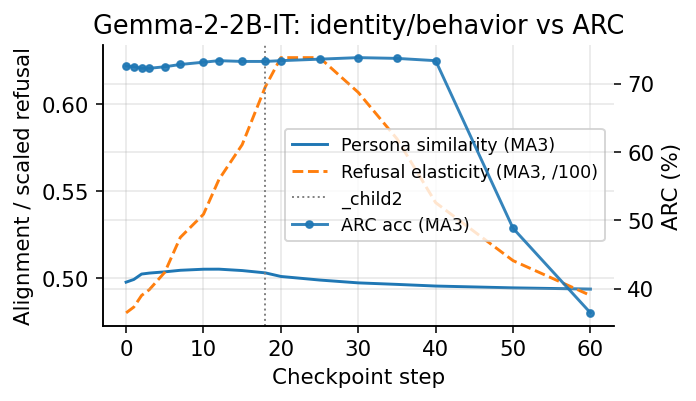

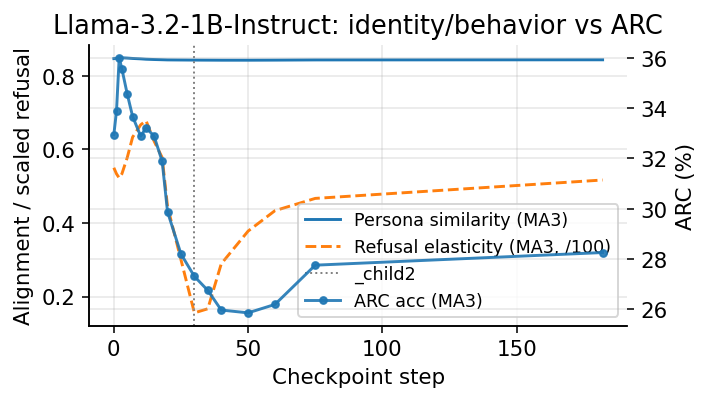

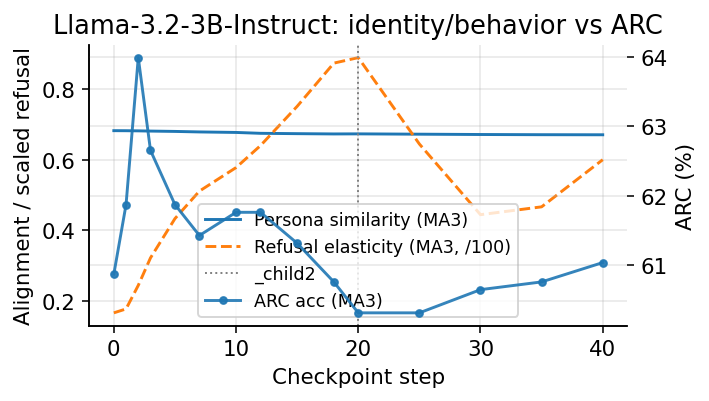

In [20]:
# %%
def plot_model_frame(g, knee, title):
    g = g.sort_values("checkpoint_step")
    x = g["checkpoint_step"].to_numpy()

    fig, ax1 = plt.subplots(figsize=(5.2, 3.0))
    ax1.plot(x, g["cos_ma3"], label="Persona similarity (MA3)")
    ax1.plot(x, g["refusal_ma3"]/100.0, "--", label="Refusal elasticity (MA3, /100)")
    ax1.axvline(knee, color="gray", ls=":", lw=1)
    ax1.set_xlabel("Checkpoint step")
    ax1.set_ylabel("Alignment / scaled refusal")

    ax2 = ax1.twinx()
    ax2.plot(x, g["arc_ma3"], marker="o", ms=3.5, label="ARC acc (MA3)", alpha=0.9)
    ax2.set_ylabel("ARC (%)")

    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="best", fontsize=9)
    ax1.set_title(title)
    plt.tight_layout()
    return fig

for model, g in all_runs.groupby("model"):
    _ = plot_model_frame(g, knees[model], f"{model}: identity/behavior vs ARC")
    plt.show()


Saved: ../results/figures/lockin_vs_arc_panel.png and ../results/figures/lockin_vs_arc_panel.pdf


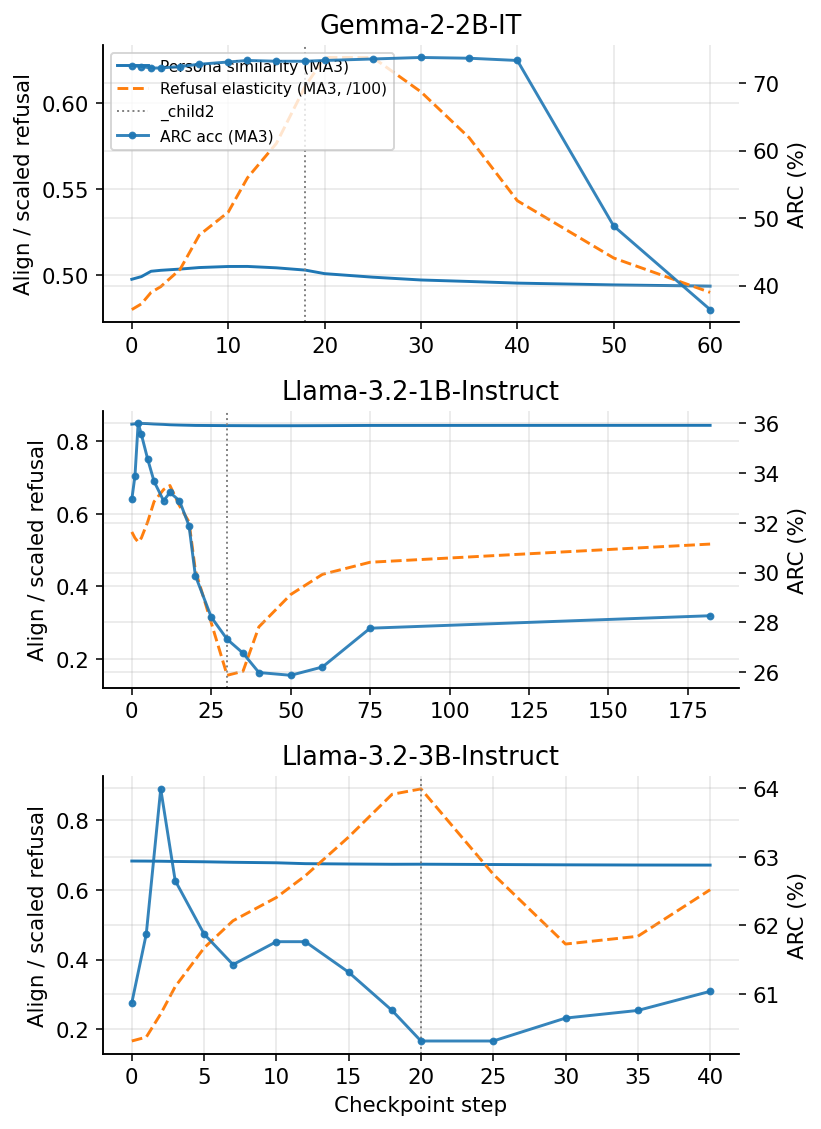

In [21]:
# %%
models_order = [PATHS["gemma"]["label"], PATHS["llama1b"]["label"], PATHS["llama3b"]["label"]]
fig, axes = plt.subplots(3, 1, figsize=(6.0, 8.2), sharex=False)

for ax, model in zip(axes, models_order):
    g = all_runs[all_runs["model"] == model].sort_values("checkpoint_step")
    x = g["checkpoint_step"].to_numpy()
    ax.plot(x, g["cos_ma3"], label="Persona similarity (MA3)")
    ax.plot(x, g["refusal_ma3"]/100.0, "--", label="Refusal elasticity (MA3, /100)")
    ax.axvline(knees[model], color="gray", ls=":", lw=1)
    ax.set_ylabel("Align / scaled refusal")
    ax.set_title(model)
    ax2 = ax.twinx()
    ax2.plot(x, g["arc_ma3"], marker="o", ms=3, label="ARC acc (MA3)", alpha=0.9)
    ax2.set_ylabel("ARC (%)")
    if ax is axes[0]:
        lines = ax.get_lines() + ax2.get_lines()
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc="upper left", fontsize=8)

axes[-1].set_xlabel("Checkpoint step")
plt.tight_layout()
import os; os.makedirs("../results/figures", exist_ok=True)
plt.savefig(OUT_FIG1, dpi=300)
plt.savefig(OUT_FIG1_PDF)
print("Saved:", OUT_FIG1, "and", OUT_FIG1_PDF)
plt.show()


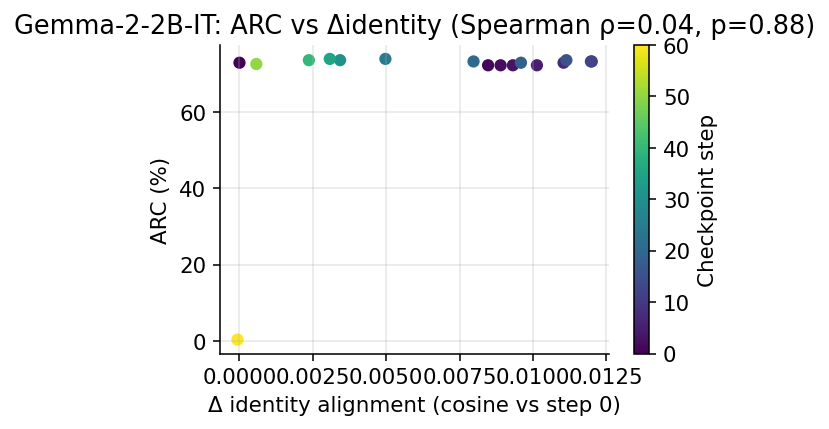

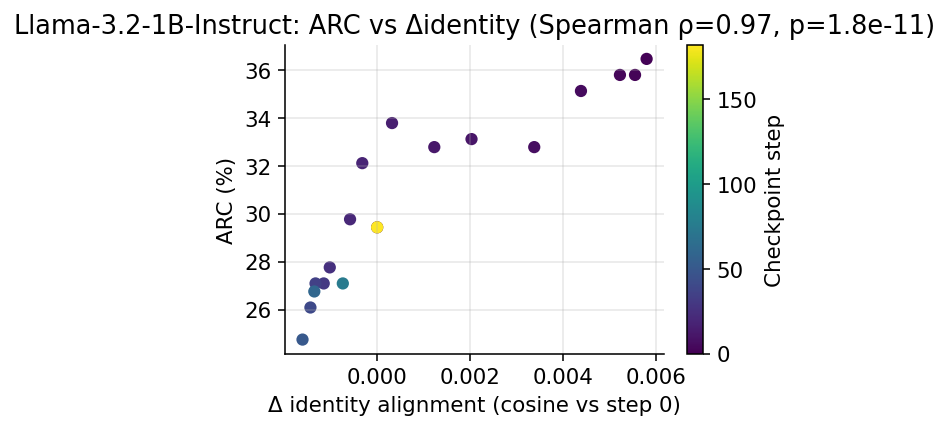

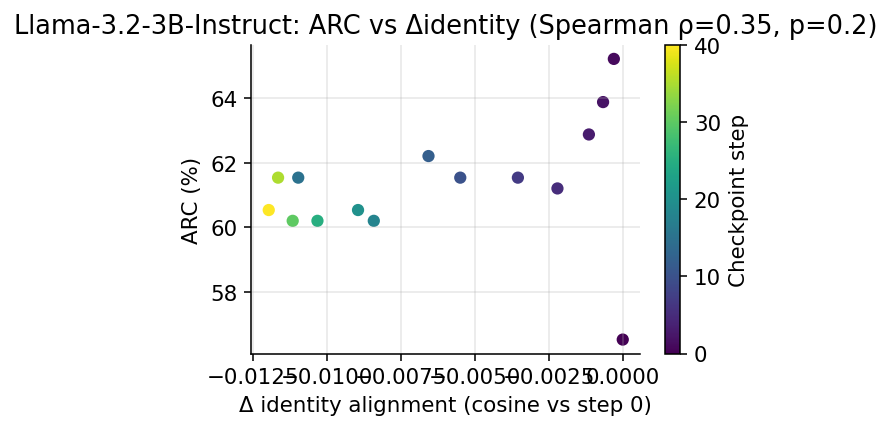

In [22]:
# %%
def add_delta_identity(g):
    g = g.copy()
    base = g.iloc[0]["persona_vector_similarity"]
    g["delta_identity"] = g["persona_vector_similarity"] - base
    return g

for model, g in all_runs.groupby("model"):
    g = add_delta_identity(g)
    r, p = spearmanr(g["delta_identity"], g["arc_challenge_acc"])
    plt.figure(figsize=(4.4,3.2))
    plt.scatter(g["delta_identity"], g["arc_challenge_acc"], c=g["checkpoint_step"], s=28, cmap="viridis")
    plt.colorbar(label="Checkpoint step")
    plt.xlabel("Δ identity alignment (cosine vs step 0)")
    plt.ylabel("ARC (%)")
    plt.title(f"{model}: ARC vs Δidentity (Spearman ρ={r:.2f}, p={p:.2g})")
    plt.tight_layout()
    plt.show()


In [33]:
import numpy as np

def knee_onset(x, y, baseline=None, add_pp=15.0, min_hold=1):
    """First step where y >= baseline + add_pp and stays for min_hold."""
    x = np.asarray(x); y = np.asarray(y, float)
    if baseline is None: baseline = float(y[0])
    thr = baseline + add_pp
    for i in range(len(y)-min_hold):
        if np.all(y[i:i+min_hold+1] >= thr):
            return int(x[i])
    return None  # no sustained onset

def knee_collapse(x, y, span_frac=0.65):
    """Step with the most negative local slope (largest drop) in the early span."""
    x = np.asarray(x); y = np.asarray(y, float)
    k = max(2, int(len(y)*span_frac))
    dx = np.diff(x[:k]); dy = np.diff(y[:k])
    slopes = dy / np.maximum(dx, 1e-9)
    j = int(np.argmin(slopes))
    return int(x[j+1])

# per model
knees_onset = {}
knees_collapse = {}
for model, g in all_runs.groupby("model"):
    g = g.sort_values("checkpoint_step")
    x = g["checkpoint_step"].to_numpy()
    re = g["refusal_ma3"].to_numpy()  # %
    knees_onset[model]    = knee_onset(x, re, add_pp=15.0, min_hold=1)
    knees_collapse[model] = knee_collapse(x, re, span_frac=0.65)


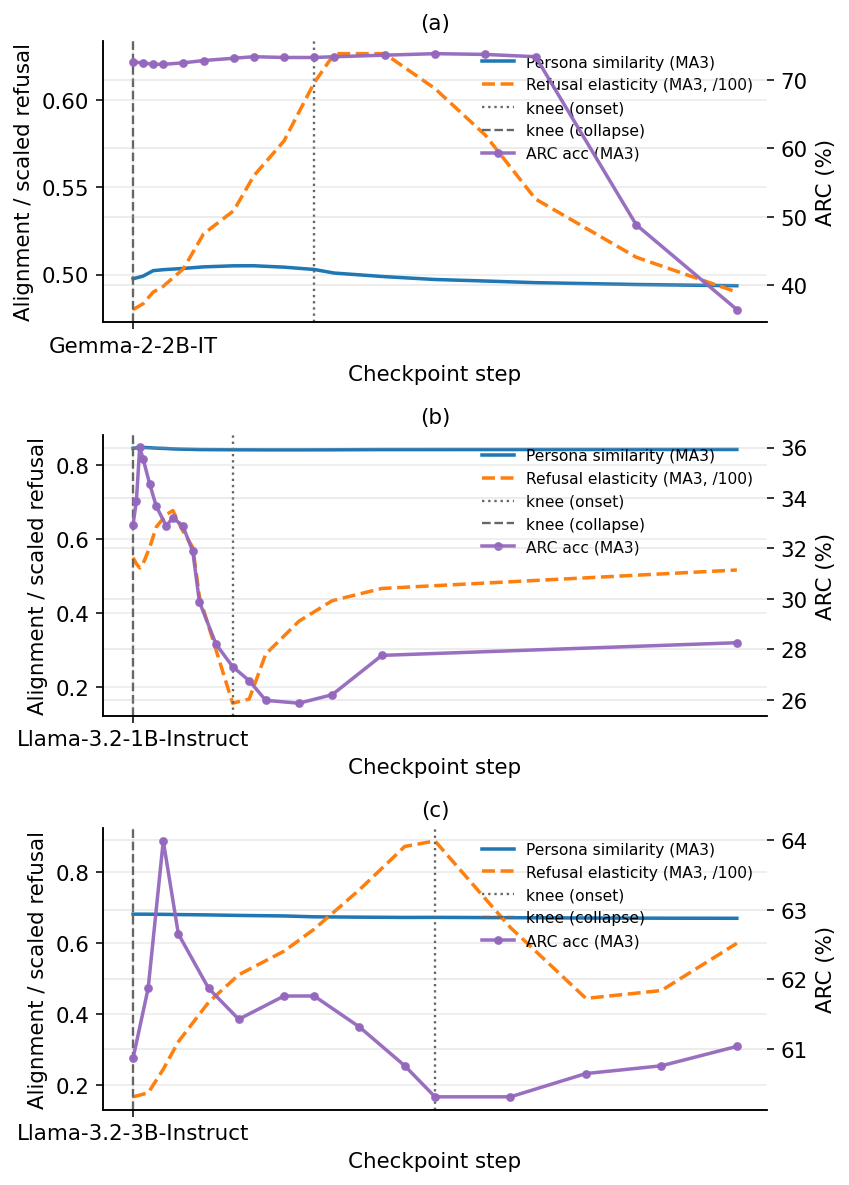

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Order + pretty labels for the three panels
PANEL_ORDER = [
    ("Gemma-2-2B-IT",      "Gemma-2-2B-IT"),
    ("Llama-3.2-1B-Instruct","Llama-3.2-1B-Instruct"),
    ("Llama-3.2-3B-Instruct","Llama-3.2-3B-Instruct"),
]

# Consistent styling
COLOR_COS   = "#1f77b4"  # blue
COLOR_RE    = "#ff7f0e"  # orange
COLOR_ARC   = "#9467bd"  # purple
LW          = 1.8
MS          = 3.5

def _one_panel(ax, df, knee_on=None, knee_col=None, title="", tag=""):
    df = df.sort_values("checkpoint_step")
    x  = df["checkpoint_step"].to_numpy()

    ax.plot(x, df["cos_ma3"], color="#1f77b4", lw=1.8, label="Persona similarity (MA3)")
    ax.plot(x, df["refusal_ma3"]/100.0, "--", color="#ff7f0e", lw=1.8, label="Refusal elasticity (MA3, /100)")
    if knee_on is not None: ax.axvline(knee_on, color="0.4", ls=":", lw=1.2, label="knee (onset)")
    if knee_col is not None: ax.axvline(knee_col, color="0.4", ls="--", lw=1.2, label="knee (collapse)")

    ax.set_xlabel("Checkpoint step"); ax.set_ylabel("Alignment / scaled refusal")
    ax2 = ax.twinx()
    ax2.plot(x, df["arc_ma3"], color="#9467bd", lw=1.8, marker="o", ms=3.5, label="ARC acc (MA3)", alpha=0.95)
    ax2.set_ylabel("ARC (%)")
    ax.set_title(title, fontsize=11)

    lines = ax.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    # de-duplicate legend labels
    uniq = dict(zip(labels, lines))
    ax.legend(uniq.values(), uniq.keys(), loc="upper right", fontsize=8, frameon=False)
    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.text(0.01, 0.97, tag, transform=ax.transAxes, ha="left", va="top", fontsize=11, fontweight="bold")


def plot_identity_vs_arc_3panel(all_runs, knees, panel_order=PANEL_ORDER, figsize=(6.2, 8.6)):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=figsize, sharex=False)
    for ax, (model_key, title), panel_tag in zip(
        axes, panel_order, ["(a)", "(b)", "(c)"]
    ):
        g = all_runs.query("model == @model_key").copy()
        if g.empty:
            ax.axis("off")
            ax.text(0.5,0.5,f"No data for {model_key}",ha="center",va="center")
            continue
        _one_panel(ax, g, knees.get(model_key, g["checkpoint_step"].min()), title, panel_tag)

    plt.tight_layout()
    return fig

# Example call:
fig = plot_identity_vs_arc_3panel(all_runs, knees)
# fig.savefig("../results/fig_identity_vs_arc.png", dpi=300, bbox_inches="tight")
# fig.savefig("../results/fig_identity_vs_arc.pdf", bbox_inches="tight")


In [36]:
import numpy as np

def _smooth_ma(y, w=3):
    y = np.asarray(y, float)
    if len(y) < 3: return y
    # centered MA, replicate at boundaries
    pad = w//2
    z = np.convolve(y, np.ones(w)/w, mode="same")
    z[:pad] = np.mean(y[:w])
    z[-pad:] = np.mean(y[-w:])
    return z

def find_knees(checkpoint_steps, refusal_pct,
               onset_delta_pp=15.0, min_hold=1,
               guard=2):
    """
    Returns (knee_onset_step or None, knee_collapse_step or None).
    - guard: exclude first/last `guard` points from consideration.
    - onset: first step where smoothed refusal >= baseline+Δ and persists for `min_hold`.
    - collapse: interior index with most negative curvature (2nd derivative), after the early peak.
    """
    x  = np.asarray(checkpoint_steps, int)
    y0 = np.asarray(refusal_pct, float)          # percent (0-100)
    y  = _smooth_ma(y0, w=3)

    n = len(y)
    if n < 1 + guard*2:
        return None, None

    # --- onset knee (sustained rise above baseline + Δ) ---
    baseline = float(y[0])
    thr = baseline + onset_delta_pp
    onset_ix = None
    for i in range(guard, n-guard-min_hold):
        if np.all(y[i:i+min_hold+1] >= thr):
            onset_ix = i
            break
    knee_onset = int(x[onset_ix]) if onset_ix is not None else None

    # --- collapse knee (max negative curvature), avoid endpoints ---
    # discrete 2nd derivative on interior
    # y''_i ≈ y[i+1] - 2*y[i] + y[i-1]
    curv = y[2:] - 2*y[1:-1] + y[:-2]
    # search only interior indices [guard .. n-guard-1] mapped to curv domain (offset by 1)
    lo = max(1+guard, 1)             # curv index maps to y index i=1..n-2
    hi = min(n-1-guard, n-1)         # exclusive
    if hi - lo >= 1:
        c_slice = curv[(lo-1):(hi-1)]
        j = np.argmin(c_slice)       # most negative curvature
        collapse_ix = (lo-1) + j + 1 # map back to y index
        knee_collapse = int(x[collapse_ix])
    else:
        knee_collapse = None

    # Optional refinement: if there is an early *peak* then a drop, prefer collapse after the peak
    peak_ix = np.argmax(y[: max(guard, n//2)]) if n >= 4 else 0
    if knee_collapse is not None:
        kc_ix = int(np.where(x == knee_collapse)[0][0])
        if kc_ix <= peak_ix + 1 and (peak_ix + 2 < n-guard):
            # move search to after the early peak
            lo2 = max(peak_ix + 1, guard+1)
            hi2 = n - 1 - guard
            if hi2 - lo2 >= 1:
                c_slice2 = curv[(lo2-1):(hi2-1)]
                j2 = np.argmin(c_slice2)
                collapse_ix = (lo2-1) + j2 + 1
                knee_collapse = int(x[collapse_ix])

    return knee_onset, knee_collapse


In [37]:
knees_onset = {}
knees_collapse = {}
for model, g in all_runs.groupby("model"):
    g = g.sort_values("checkpoint_step")
    k_on, k_col = find_knees(g["checkpoint_step"], g["refusal_ma3"],
                             onset_delta_pp=15.0, min_hold=1, guard=2)
    knees_onset[model] = k_on
    knees_collapse[model] = k_col


In [30]:
def _nice_step_ticks(x, max_ticks=8):
    x = np.asarray(x, int)
    if len(x) <= max_ticks: return x
    # choose ~max_ticks evenly spaced from the actual step values
    idx = np.linspace(0, len(x)-1, num=max_ticks, dtype=int)
    return np.unique(x[idx])

def plot_model_frame(g, knee_on, knee_col, title, tag=""):
    g = g.sort_values("checkpoint_step")
    x = g["checkpoint_step"].to_numpy()

    fig, ax1 = plt.subplots(figsize=(5.4, 3.1))
    # left axis
    ax1.plot(x, g["cos_ma3"], label="Persona similarity (MA3)", lw=1.8)
    ax1.plot(x, g["refusal_ma3"]/100.0, "--", label="Refusal elasticity (MA3, /100)", lw=1.8)
    if knee_on is not None:  ax1.axvline(knee_on, color="0.35", ls=":",  lw=1.2, label="knee (onset)")
    if knee_col is not None: ax1.axvline(knee_col, color="0.35", ls="--", lw=1.2, label="knee (collapse)")
    ax1.set_xlabel("Checkpoint step")
    ax1.set_ylabel("Alignment / scaled refusal")

    # force readable ticks
    ticks = _nice_step_ticks(x, max_ticks=8)
    ax1.set_xticks(ticks)
    ax1.set_xticklabels([str(t) for t in ticks])

    # lightly annotate a few step numbers on the ARC curve
    ax2 = ax1.twinx()
    ax2.plot(x, g["arc_ma3"], marker="o", ms=3.3, lw=1.8, alpha=0.95, label="ARC acc (MA3)")
    ax2.set_ylabel("ARC (%)")
    # annotate first/median/last
    for t in [x[0], x[len(x)//2], x[-1]]:
        y = float(g.loc[g["checkpoint_step"] == t, "arc_ma3"])
        ax2.annotate(f"{t}", xy=(t, y), xytext=(0, 6), textcoords="offset points",
                     ha="center", va="bottom", fontsize=8, alpha=0.8)

    # legend (de-dup)
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    uniq = dict(zip(labels, lines))
    ax1.legend(uniq.values(), uniq.keys(), loc="upper right", fontsize=8, frameon=False)

    ax1.set_title(title, fontsize=11)
    ax1.grid(True, alpha=0.25, linewidth=0.8)
    ax1.text(0.01, 0.97, tag, transform=ax1.transAxes, ha="left", va="top",
             fontsize=11, fontweight="bold")
    plt.tight_layout()
    return fig


In [31]:
for model, g in all_runs.groupby("model"):
    fig = plot_model_frame(
        g,
        knee_on=knees_onset.get(model),
        knee_col=knees_collapse.get(model),
        title=PATHS[model]["label"],
        tag={"gemma":"(a)","llama1b":"(b)","llama3b":"(c)"}[model]
    )
    plt.show()


KeyError: 'Gemma-2-2B-IT'